In [1]:
# Install required packages
!pip install kagglehub -q >nul 2>&1
%pip install scikit-learn pandas numpy matplotlib seaborn -q >nul 2>&1

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score,  f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
from collections import Counter

In [2]:
# Load the latest version of the dataset directly into a pandas DataFrame
file_path = r"C:\Users\mail2\OneDrive\Desktop\MY_DRIVE\MLOps\MLOps-Addy\Data_Sets\time-series_weather_dataset.csv"
dataset = pd.read_csv(file_path)
dataset.head(10)

,datetime_local,temperature,humidity,dew_point,wind_bearing,wind_speed,wind_gust,pressure,uv_index,ozone,precip_intensity,icon
0,01-10-2019 00:00,26.0,1.0,22.01,101.0,3.08,6.42,1008.45,0.0,268.6,0.0,partly-cloudy-night
1,01-10-2019 01:00,25.0,1.0,22.06,105.0,2.94,6.28,1008.24,0.0,269.1,0.0,partly-cloudy-night
2,01-10-2019 02:00,25.0,1.0,22.06,106.0,2.82,6.08,1007.90,0.0,269.7,0.0,partly-cloudy-night
3,01-10-2019 03:00,24.0,1.0,21.87,106.0,2.63,5.74,1007.61,0.0,270.4,0.0,partly-cloudy-night
4,01-10-2019 04:00,23.0,1.0,21.53,100.0,2.39,5.30,1007.51,0.0,271.3,0.0,partly-cloudy-night
5,01-10-2019 05:00,23.0,1.0,21.56,94.0,2.09,4.47,1008.03,0.0,271.6,0.0,partly-cloudy-night
6,01-10-2019 06:00,24.0,1.0,21.97,95.0,2.31,4.07,1008.61,0.0,271.8,0.0,partly-cloudy-night
7,01-10-2019 07:00,25.0,1.0,22.34,96.0,2.98,4.65,1008.97,0.0,272.4,0.0,partly-cloudy-day
8,01-10-2019 08:00,25.0,1.0,22.35,99.0,3.44,5.14,1009.53,1.0,272.8,0.0,partly-cloudy-day
9,01-10-2019 09:00,27.0,1.0,22.21,102.0,3.49,4.77,1010.00,3.0,272.6,0.0,partly-cloudy-day


In [3]:
# Basic dataset information
dataset.shape
dataset.info()
dataset.columns
dataset.describe()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   datetime_local    499 non-null    object 
 1   temperature       499 non-null    float64
 2   humidity          499 non-null    float64
 3   dew_point         499 non-null    float64
 4   wind_bearing      499 non-null    float64
 5   wind_speed        499 non-null    float64
 6   wind_gust         499 non-null    float64
 7   pressure          499 non-null    float64
 8   uv_index          499 non-null    float64
 9   ozone             499 non-null    float64
 10  precip_intensity  499 non-null    float64
 11  icon              499 non-null    object 
dtypes: float64(10), object(2)
memory usage: 60.9+ KB


,temperature,humidity,dew_point,wind_bearing,wind_speed,wind_gust,pressure,uv_index,ozone,precip_intensity
count,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000,499.000000
mean,27.797595,0.541082,15.871303,139.523046,2.267114,3.616974,1011.535411,1.641283,276.195792,0.009820
std,4.305725,0.498809,3.065238,118.438353,0.755191,1.608687,1.932765,2.493683,2.788063,0.036247
min,19.000000,0.000000,5.740000,0.000000,0.600000,0.840000,1005.970000,0.000000,268.600000,0.000000
25%,24.000000,0.000000,14.025000,44.000000,1.780000,2.460000,1010.235000,0.000000,274.600000,0.000000
50%,27.000000,1.000000,15.710000,105.000000,2.200000,3.220000,1011.430000,0.000000,276.100000,0.000000
75%,32.000000,1.000000,17.990000,217.500000,2.780000,4.345000,1012.675000,3.000000,277.800000,0.000000
max,36.000000,1.000000,22.350000,359.000000,4.180000,10.540000,1016.900000,8.000000,284.900000,0.420000


In [27]:
scaler = StandardScaler().fit_transform(dataset.loc[:,dataset.columns!='Class'])
scaled_data = scaler[0:40000]
df = pd.DataFrame(data=scaled_data)
X = dataset.drop(columns=['icon'])
y = dataset['icon']

In [36]:
# Isolation forest for Anomaly Detection
from sklearn.ensemble import IsolationForest
outlier_fraction = len(dataset[dataset['icon']== 1])/float(len(dataset))
print("Outlier fraction:", outlier_fraction)
iso_forest = IsolationForest(n_estimators=100, contamination=outlier_fraction, random_state=42)
iso_forest.fit(dataset)

Outlier fraction: 0.364


,n_estimators,100
,max_samples,'auto'
,contamination,0.364
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [38]:
# Scores prediction
score_predection=iso_forest.decision_function(dataset)
anomaly_prediction=iso_forest.predict(dataset)
anomaly_prediction[anomaly_prediction==1]=0
anomaly_prediction[anomaly_prediction==-1]=1
print("Anomaly predictions:", accuracy_score(y, anomaly_prediction))

Anomaly predictions: 0.142


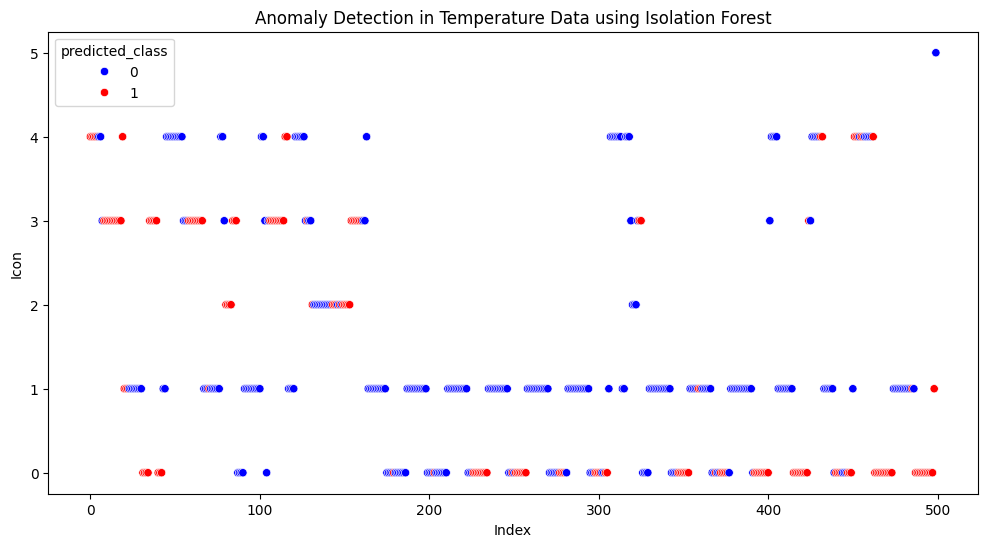

In [49]:
# Visualizing the anomalies for "Field" ??????????
y_features = dataset['icon']
dataset['predicted_class'] = anomaly_prediction
plt.figure(figsize=(12,6))
sns.scatterplot(x=dataset.index, y=y_features, hue='predicted_class', data=dataset, palette={0:'blue', 1:'red'})
plt.title("Anomaly Detection in Temperature Data using Isolation Forest")
plt.xlabel("Index")
plt.ylabel("Icon")
plt.show()

In [42]:
# Identify categorical, integer, and float columns
obj = (dataset.dtypes == 'object')
object_cols = list(obj[obj].index)
print("Categorical variables:",len(object_cols))

int_ = (dataset.dtypes == 'int')
num_cols = list(int_[int_].index)
print("Integer variables:",len(num_cols))

fl = (dataset.dtypes == 'float')
fl_cols = list(fl[fl].index)
print("Float variables:",len(fl_cols))

Categorical variables: 0
Integer variables: 2
Float variables: 10


In [43]:
# Check for missing/null values
dataset.isnull().sum()

temperature         1
humidity            1
dew_point           1
wind_bearing        1
wind_speed          1
wind_gust           1
pressure            1
uv_index            1
ozone               1
precip_intensity    1
icon                0
predicted_class     0
dtype: int64

In [44]:
# Remove duplicates and print if any duplicates were found
print("Duplicates:", dataset.duplicated().sum())

Duplicates: 0


In [45]:
#Drop duplicate rows if any
dataset = dataset.drop_duplicates()
print("Duplicates after dropping:", dataset.duplicated().sum())

Duplicates after dropping: 0


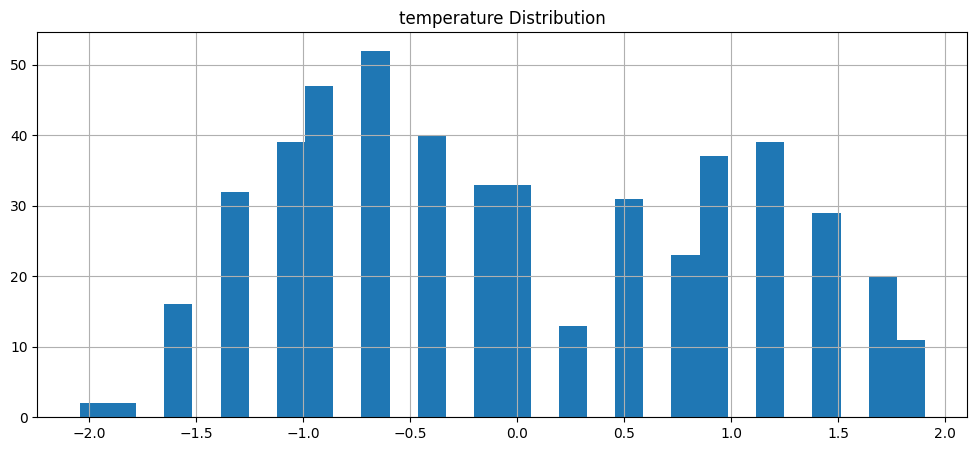

In [46]:
plt.figure(figsize=(12,5))
dataset['temperature'].hist(bins=30)
plt.title("temperature Distribution")
plt.show()

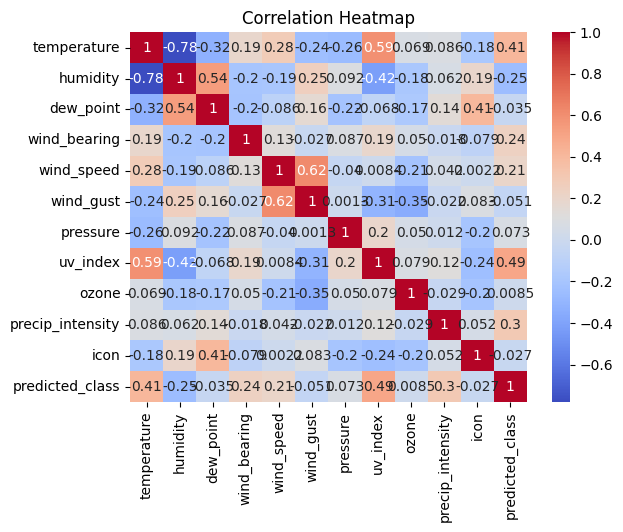

In [47]:
# Correlation Heatmap
numeric_dataset = dataset.select_dtypes(include=[np.number])
sns.heatmap(numeric_dataset.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [48]:
# Anamoly Detection using Z-Score
from scipy import stats
z_scores = np.abs(stats.zscore(numeric_dataset))
threshold = 3 
anomalies = np.where(z_scores > threshold)
print("Anomalies detected at indices:", anomalies)

Anomalies detected at indices: (array([], dtype=int64), array([], dtype=int64))


In [ ]:
# Standardize numerical features
scaler = StandardScaler()
numeric_cols = numeric_dataset.columns.tolist()
dataset[numeric_cols] = scaler.fit_transform(dataset[numeric_cols])
# Drop date column
dataset = dataset.drop(columns=['datetime_local'])
dataset.head()

,temperature,humidity,dew_point,wind_bearing,wind_speed,wind_gust,pressure,uv_index,ozone,precip_intensity,icon
0,-0.417908,0.92095,2.004692,-0.325585,1.077477,1.744179,-1.597974,-0.658837,-2.727131,-0.271183,4
1,-0.650390,0.92095,2.021020,-0.291778,0.891908,1.657064,-1.706735,-0.658837,-2.547615,-0.271183,4
2,-0.650390,0.92095,2.021020,-0.283326,0.732848,1.532614,-1.882826,-0.658837,-2.332196,-0.271183,4
3,-0.882872,0.92095,1.958972,-0.283326,0.481004,1.321050,-2.033021,-0.658837,-2.080874,-0.271183,4
4,-1.115354,0.92095,1.847940,-0.334036,0.162885,1.047261,-2.084812,-0.658837,-1.757745,-0.271183,4


In [50]:
# Prepare feature matrix X and target vector y
target_column = 'icon'
X=dataset.drop(columns=[target_column])
y=dataset[target_column]

# Split into training and testing data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)   
# Train a Random Forest Classifier
rf=RandomForestClassifier(random_state=42)
rf.fit(X,y)
y_pred=rf.predict(X)
accuracy=accuracy_score(y,y_pred)
print(f"Accuracy: {accuracy:.2f}")



Accuracy: 1.00


In [29]:
# To identify and select the most important features
rf.feature_importances_

array([0.05061664, 0.01147345, 0.08782225, 0.09047977, 0.02430364,
       0.06843961, 0.11857152, 0.12244627, 0.11172839, 0.31411844])

In [30]:
# To identify and select the most important features
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)
selected_features = importances.head(10).index.tolist()
print("Selected Features:", selected_features)
X_selected = dataset[selected_features]

RecruitmentStrategy    0.314118
SkillScore             0.122446
InterviewScore         0.118572
PersonalityScore       0.111728
ExperienceYears        0.090480
EducationLevel         0.087822
DistanceFromCompany    0.068440
Age                    0.050617
PreviousCompanies      0.024304
Gender                 0.011473
dtype: float64
Selected Features: ['RecruitmentStrategy', 'SkillScore', 'InterviewScore', 'PersonalityScore', 'ExperienceYears', 'EducationLevel', 'DistanceFromCompany', 'Age', 'PreviousCompanies', 'Gender']


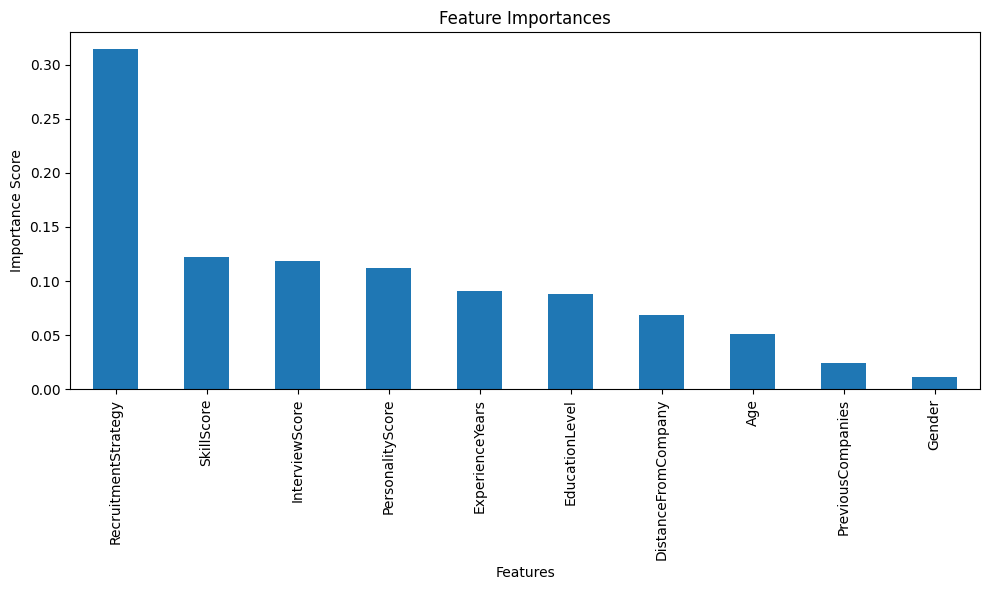

In [31]:
# Visualize Feature Importances
plt.figure(figsize=(10,6))
importances.plot(kind='bar')
plt.title("Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [32]:
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


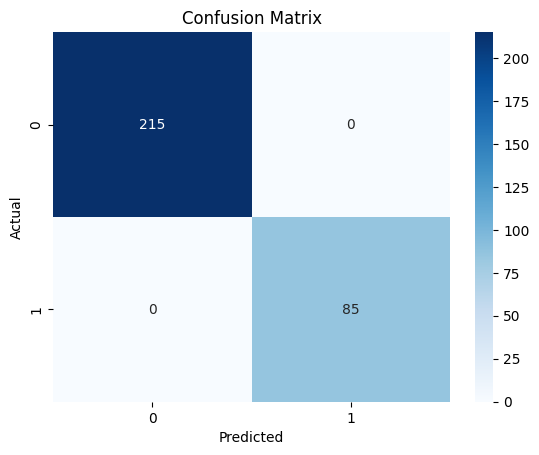

In [33]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
# Hyperparameter Tuning - Cross Validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X_train, y_train, cv=5)
print("Cross-validation scores:", scores)
print("Mean cross-validation score:", scores.mean())


Cross-validation scores: [0.91666667 0.9125     0.92916667 0.925      0.8875    ]
Mean cross-validation score: 0.9141666666666668


In [35]:
# Make predictions - Before Hyperparameter
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       215
           1       1.00      1.00      1.00        85

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [36]:
# Hyperparameter Tuning using GridSearchCV - Fitting 3 folds for each of 72 candidates, totalling 216 fits
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3,scoring='accuracy' ,n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)
best_rf = grid_search.best_estimator_
print("Test Set Accuracy:", best_rf.score(X_test, y_test))

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Best Cross-validation Score: 0.9216666666666667
Test Set Accuracy: 0.94


In [37]:
# Make predictions
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred))



Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       215
           1       1.00      1.00      1.00        85

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [ ]:
# Hyperparameter Tuning using GridSearchCV - Fitting 5 folds for each of 72 candidates, totalling 360 fits
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5,scoring='accuracy' ,n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)
best_rf = grid_search.best_estimator_
print("Test Set Accuracy:", best_rf.score(X_test, y_test))

Fitting 15 folds for each of 72 candidates, totalling 1080 fits
Best Parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-validation Score: 0.9458333333333334
Test Set Accuracy: 0.9433333333333334


In [ ]:
# Make predictions
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred))

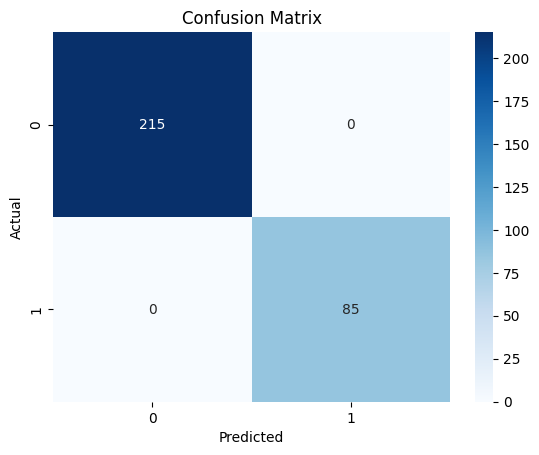

In [38]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
